In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

from scipy.signal import periodogram, get_window, firwin, filtfilt

### Data

In [10]:
CITY_NAME = "Tokyo"
TZ        = "Asia/Tokyo"
YEARS     = (2018, 2024)   # inclusive start year, exclusive end year bound below
SIG_COL   = "temp"         # Meteostat hourly temperature column
SEED      = 42
DAYS_KEEP = 10    # use last N whole days for clean comparisons

In [11]:
def style_float(df, fmt_map):
    return df.style.format(fmt_map)


def to_hours(timedelta_index):
    return timedelta_index.total_seconds() / 3600.0


def fetch_tokyo_hourly(start_year=YEARS[0], end_year=YEARS[1], tz=TZ, sig_col=SIG_COL):
    """
    Fetch Hourly Meteostat data for Tokyo, strictly hourly, tiny-gap fill (≤3h),
    in local timezone. Returns df_hourly with column 'x' (float).
    """
    try:
        # Lazy import so the notebook runs even if Meteostat isn't installed yet
        from meteostat import Hourly, Point
        from datetime import datetime

        TOKYO = Point(35.6762, 139.6503)
        start = datetime(start_year, 1, 1)
        # end is exclusive; fetch up to end-1 day
        end = datetime(end_year, 12, 31, 23, 0)

        raw = Hourly(TOKYO, start, end, timezone="UTC").fetch()
        if raw is None or raw.empty:
            raise RuntimeError("Meteostat returned empty frame.")

        if raw.index.tz is None:
            raw = raw.tz_localize("UTC")
        raw = raw.tz_convert(tz)

        # strict hourly grid; conservative fill
        df = raw[[sig_col]].copy().rename(columns={sig_col: "x"})
        df = df.resample("1h").mean().ffill(limit=3).dropna()
        # basic sanity (temperature numeric)
        df["x"] = pd.to_numeric(df["x"], errors="coerce")
        df = df.dropna()
        # make index tz-naive duration (hours from start) for uniformity later
        # (keep the original index around if you want)
        return df

    except Exception as e:
        print(f"[WARN] Meteostat fetch failed ({e}). Using synthetic fallback.")
        return None


def make_synthetic_tokyo(days=14, noise_sigma=0.8, seed=SEED):
    """
    5-minute surrogate with 24h / 12h / 8h cycles + slow drift & noise.
    Returns hourly df with column 'x'.
    """
    rng = np.random.default_rng(seed)
    dt_true = 1 / 12  # 5 min in hours
    t = np.arange(0, 24 * days, dt_true)  # hours

    base = 19.0
    drift = 2.5 * np.sin(2 * np.pi * t / (24 * days * 2))
    comp = (6.0 * np.sin(2 * np.pi * t / 24.0)  # 24 h
            + 1.5 * np.sin(2 * np.pi * t / 12.0)  # 12 h
            + 0.7 * np.sin(2 * np.pi * t / 8.0)  # 8 h
            )
    x = base + drift + comp + rng.normal(0, noise_sigma, t.size)
    idx = pd.to_timedelta(t, unit="h")
    df5 = pd.DataFrame({"x": x}, index=idx)
    return df5.resample("1h").mean()


def get_hourly_series():
    df = fetch_tokyo_hourly()
    if df is None:
        df = make_synthetic_tokyo(days=20)
    # keep last N whole days
    N = 24 * DAYS_KEEP
    df = df.iloc[-N:].copy()
    df["x"] = df["x"].astype(float)
    return df

## Day 1

**Country:** Japan (Tokyo)

**Use case (WHAT):** Smart-building HVAC control and urban heat monitoring in **Tokyo** rely on near-surface air temperature to detect daily warming/cooling patterns and short sub-daily swings (e.g., midday peaks).
**Chosen 1D signal:** Outdoor air temperature in °C measured at a fixed point in Tokyo.

**Problem statement:**
Find the **coarsest** sampling interval that preserves the temperature cycles required by operations analytics, specifically the **diurnal (24 h)** cycle and selected **sub-daily** harmonics (12 h and optionally 8 h) **without aliasing**.

### WHY Nyquist matters here
- **Control accuracy:** Aliasing can distort day/night deltas used in ventilation/energy strategies.
- **KPI integrity:** Mis-sampled data smears sub-daily peaks, biasing load forecasts and heat-health alerts.
- **Storage/bandwidth:** If we must downsample, we need a principled lower bound on sampling rate.

In [15]:
@dataclass
class Cadence:
    Ts_h: float         # sample interval [h]
    fs_h: float         # sample rate [1/h]
    fN_h: float         # Nyquist [1/h]
    fN_per_day: float   # Nyquist [cycles/day]

def cadence_table(Ts_list=(1, 3, 6, 12, 24)):
    rows = []
    for Ts in Ts_list:
        fs = 1.0 / Ts
        fN = fs / 2.0
        rows.append(Cadence(Ts, fs, fN, fN*24).__dict__)
    return pd.DataFrame(rows)

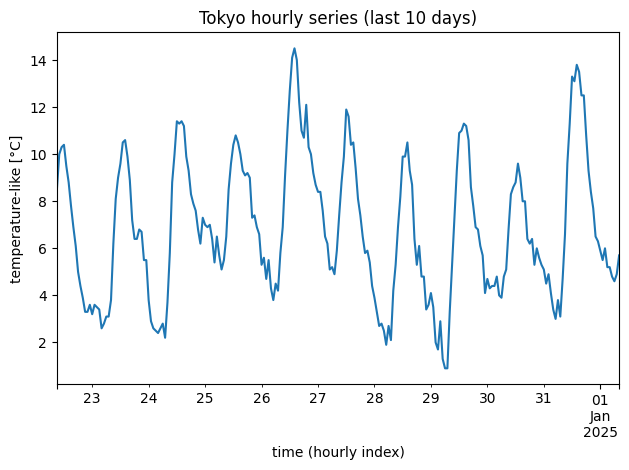

In [16]:
df_hourly = get_hourly_series()
x_hourly = df_hourly["x"].to_numpy()
t_hourly = np.arange(len(df_hourly))  # hours relative (0..H-1)

ax = df_hourly["x"].plot()
ax.set_title(f"{CITY_NAME} hourly series (last {DAYS_KEEP} days)")
ax.set_xlabel("time (hourly index)")
ax.set_ylabel("temperature-like [°C]")
plt.tight_layout();
plt.show()

In [17]:
# key frequency components for temperature control analytics
df_components = pd.DataFrame([
    {"component":"diurnal",      "period_h":24.0, "f_h":1/24.0, "f_day": 1.0},
    {"component":"semidiurnal",  "period_h":12.0, "f_h":1/12.0, "f_day": 2.0},
    {"component":"8h harmonic",  "period_h": 8.0, "f_h":1/ 8.0, "f_day": 3.0},
])

df_cadence = cadence_table()
display(style_float(df_cadence, {"fs_h":"{:.3f}", "fN_h":"{:.3f}", "fN_per_day":"{:.1f}"}))
display(style_float(df_components, {"period_h":"{:.1f}", "f_h":"{:.3f}", "f_day":"{:.1f}"}))

,Ts_h,fs_h,fN_h,fN_per_day
0,1,1.000,0.500,12.0
1,3,0.333,0.167,4.0
2,6,0.167,0.083,2.0
3,12,0.083,0.042,1.0
4,24,0.042,0.021,0.5


,component,period_h,f_h,f_day
0,diurnal,24.0,0.042,1.0
1,semidiurnal,12.0,0.083,2.0
2,8h harmonic,8.0,0.125,3.0
